# Student Performance Prediction

## Project Overview

This project aims to predict students' mathematics scores using demographic and academic factors such as gender, lunch type, test preparation course, reading score, and writing score.

A Machine Learning regression approach using Linear Regression is implemented to estimate student performance and identify the key factors affecting mathematics scores.

The project follows a complete Machine Learning workflow including data preprocessing, exploratory data analysis (EDA), feature engineering, categorical encoding, model training, evaluation, feature importance analysis, and model saving.

In [279]:
import pandas as pd
import numpy as np

## 1. Importing Libraries

In [280]:
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully")

All libraries imported successfully


### Dataset Description

The dataset contains information about students' demographic background and academic performance.

It includes features such as gender, parental education level, lunch type, test preparation course, reading score, writing score, and the target variable (math score).

The dataset contains 1000 student records with 8 original features.

## 2. Loading the Dataset & Dataset Overview

In [281]:
df = pd.read_csv("../Dataset/StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [282]:
df.shape

(1000, 8)

In [283]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 103.5 KB


In [284]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


## 3. Data Cleaning and Validation

In [285]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [286]:
df.duplicated().sum()

np.int64(0)

In [287]:
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.replace("/", "_")

df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='str')

## 4. Feature Engineering

In [288]:
df["average_score"] = (
    df["math_score"] +
    df["reading_score"] +
    df["writing_score"]
) / 3


df["test_prep_completed"] = (
    df["test_preparation_course"] == "completed"
).astype(int)

df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,average_score,test_prep_completed
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,0
1,female,group C,some college,standard,completed,69,90,88,82.333333,1
2,female,group B,master's degree,standard,none,90,95,93,92.666667,0
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,0
4,male,group C,some college,standard,none,76,78,75,76.333333,0


In [289]:
df[['math_score','reading_score','writing_score']].describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [290]:
(df[['math_score','reading_score','writing_score']] >= 0).all()

math_score       True
reading_score    True
writing_score    True
dtype: bool

In [291]:
(df[['math_score','reading_score','writing_score']] <= 100).all()

math_score       True
reading_score    True
writing_score    True
dtype: bool

## 5. Exploratory Data Analysis (EDA)

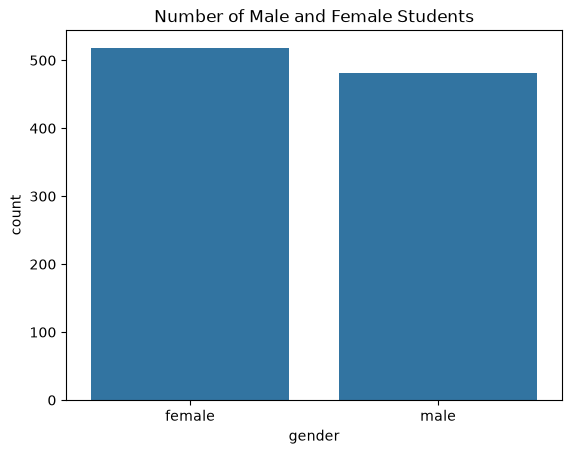

In [292]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="gender", data=df)
plt.title("Number of Male and Female Students")
plt.savefig("../Images/gender_distribution.png")
plt.show()

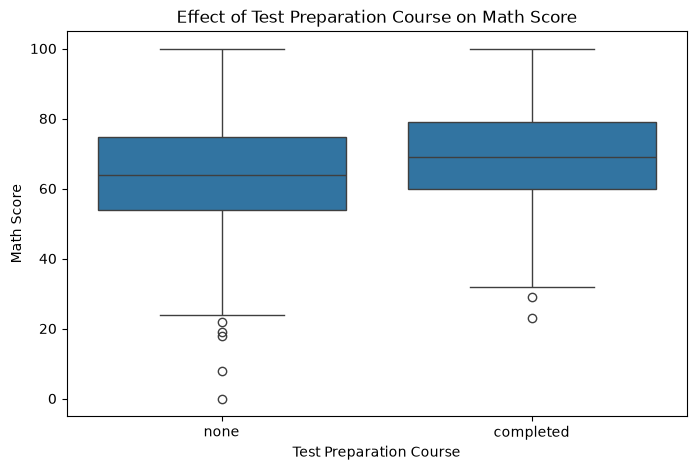

In [293]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="test_preparation_course",
    y="math_score",
    data=df
)

plt.title("Effect of Test Preparation Course on Math Score")
plt.xlabel("Test Preparation Course")
plt.ylabel("Math Score")

plt.savefig("../Images/test_preparation_boxplot.png")

plt.show()

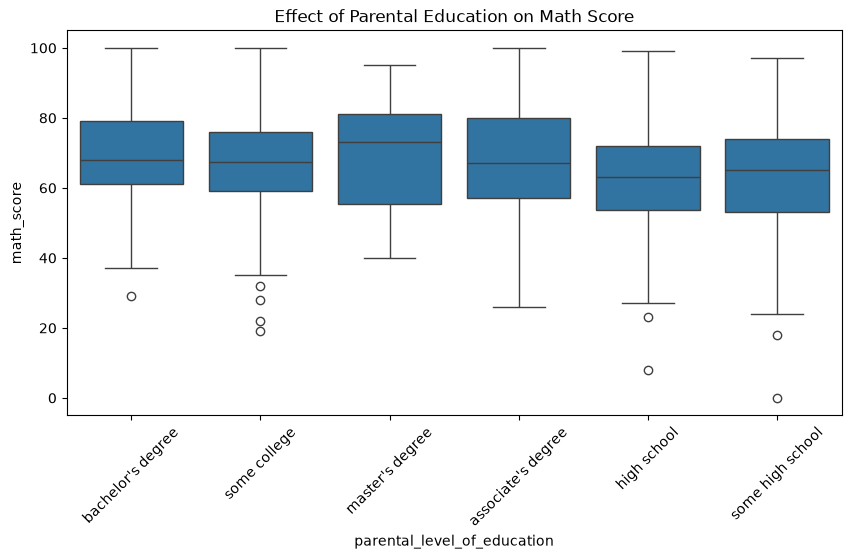

In [294]:
plt.figure(figsize=(10,5))

sns.boxplot(x="parental_level_of_education", 
            y="math_score", 
            data=df)

plt.xticks(rotation=45)
plt.title("Effect of Parental Education on Math Score")
plt.show()

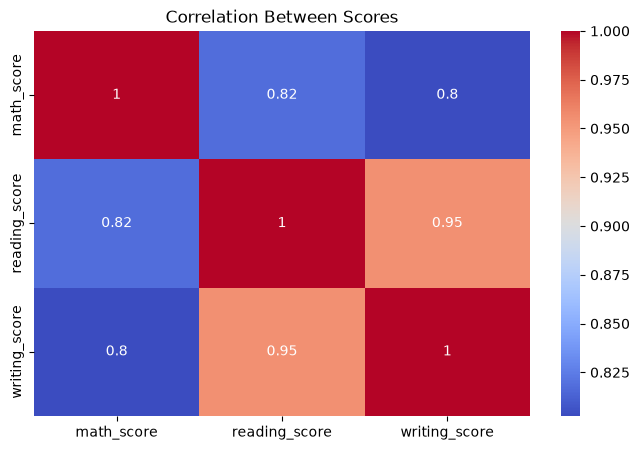

In [295]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df[['math_score','reading_score','writing_score']].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Scores")
plt.savefig("../Images/correlation_heatmap.png")
plt.show()

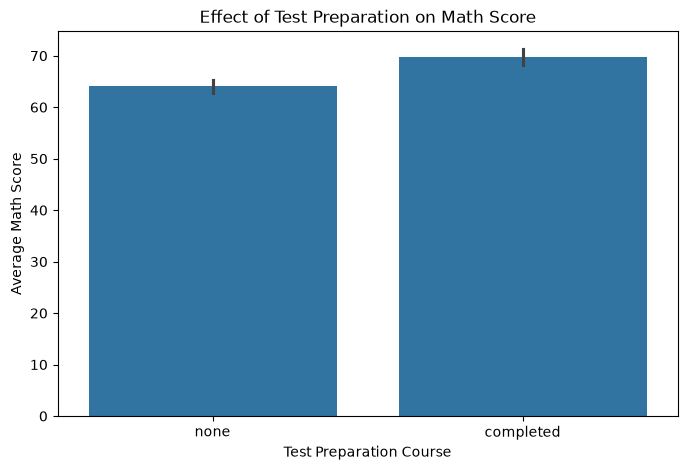

In [296]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="test_preparation_course",
    y="math_score"
)

plt.title("Effect of Test Preparation on Math Score")
plt.xlabel("Test Preparation Course")
plt.ylabel("Average Math Score")

plt.savefig("../Images/test_preparation.png")

plt.show()

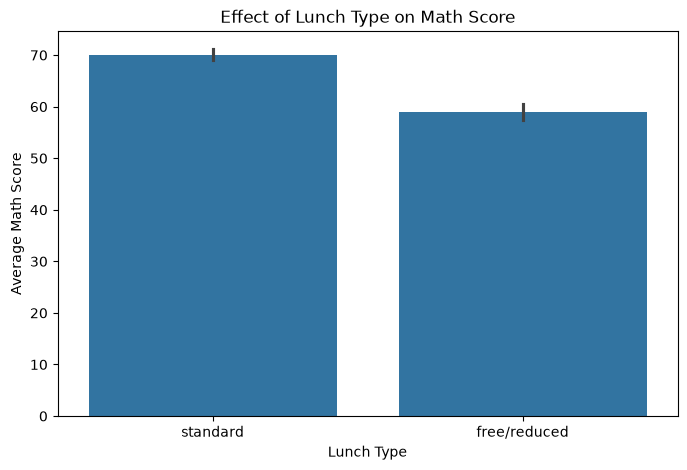

In [297]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="lunch",
    y="math_score"
)

plt.title("Effect of Lunch Type on Math Score")
plt.xlabel("Lunch Type")
plt.ylabel("Average Math Score")

plt.savefig("../Images/lunch_vs_math_score.png")

plt.show()

### EDA Insights

1. Students who completed the test preparation course achieved higher average math scores compared to students who did not complete it.

2. Students with standard lunch generally performed better than students with free/reduced lunch.

3. Reading and writing scores show a strong positive relationship with math scores, indicating that students performing well in one subject tend to perform well in others.

4. Academic performance-related features such as reading and writing scores are strong indicators for predicting mathematics performance.

In [298]:
df.select_dtypes(include="string").columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course'],
      dtype='str')

In [299]:
for col in df.select_dtypes(include="string").columns:
    print(col)
    print(df[col].unique())
    print("----------------")

gender
<ArrowStringArray>
['female', 'male']
Length: 2, dtype: str
----------------
race_ethnicity
<ArrowStringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
----------------
parental_level_of_education
<ArrowStringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
----------------
lunch
<ArrowStringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
----------------
test_preparation_course
<ArrowStringArray>
['none', 'completed']
Length: 2, dtype: str
----------------


In [300]:
df_model = df.drop(
    [
        "average_score",
        "parental_level_of_education",
        "race_ethnicity",
        "test_prep_completed"
    ],
    axis=1
)

df_model.head()

,gender,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,standard,none,72,72,74
1,female,standard,completed,69,90,88
2,female,standard,none,90,95,93
3,male,free/reduced,none,47,57,44
4,male,standard,none,76,78,75


## 6. Data Encoding

In [301]:
df_encoded = pd.get_dummies(df_model, drop_first=True)

print(df_encoded.shape)
df_encoded.head()

(1000, 6)


,math_score,reading_score,writing_score,gender_male,lunch_standard,test_preparation_course_none
0,72,72,74,False,True,True
1,69,90,88,False,True,False
2,90,95,93,False,True,True
3,47,57,44,True,False,True
4,76,78,75,True,True,True


In [302]:
df_encoded.shape

(1000, 6)

In [303]:
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   math_score                    1000 non-null   int64
 1   reading_score                 1000 non-null   int64
 2   writing_score                 1000 non-null   int64
 3   gender_male                   1000 non-null   bool 
 4   lunch_standard                1000 non-null   bool 
 5   test_preparation_course_none  1000 non-null   bool 
dtypes: bool(3), int64(3)
memory usage: 26.5 KB


In [304]:
df_encoded = df_encoded.astype(int)
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   math_score                    1000 non-null   int64
 1   reading_score                 1000 non-null   int64
 2   writing_score                 1000 non-null   int64
 3   gender_male                   1000 non-null   int64
 4   lunch_standard                1000 non-null   int64
 5   test_preparation_course_none  1000 non-null   int64
dtypes: int64(6)
memory usage: 47.0 KB


## 7. Feature Selection

In [305]:
X = df_encoded.drop("math_score", axis=1)
y = df_encoded["math_score"]

print(X.shape)
print(y.shape)

(1000, 5)
(1000,)


## 8. Train-Test Split

In [306]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 5)
(200, 5)
(800,)
(200,)


## 9. Model Building

In [307]:
from sklearn.linear_model import LinearRegression

In [308]:
model = LinearRegression()

In [309]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 0.31, 0.64,13. , 3.73, 2.84]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['reading_score','writing_score','gender_male','lunch_standard', 'test_preparation_course_none']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-9.928
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,5


In [310]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

feature_importance

,Feature,Coefficient
2,gender_male,13.003536
3,lunch_standard,3.733109
4,test_preparation_course_none,2.843186
1,writing_score,0.644301
0,reading_score,0.314355


In [311]:
y_pred = model.predict(X_test)


### Actual vs Predicted Values

This scatter plot compares the actual mathematics scores with the scores predicted by the Linear Regression model.

Points closer to the actual values indicate better prediction performance. The visualization helps evaluate how well the model predictions match the real student scores.

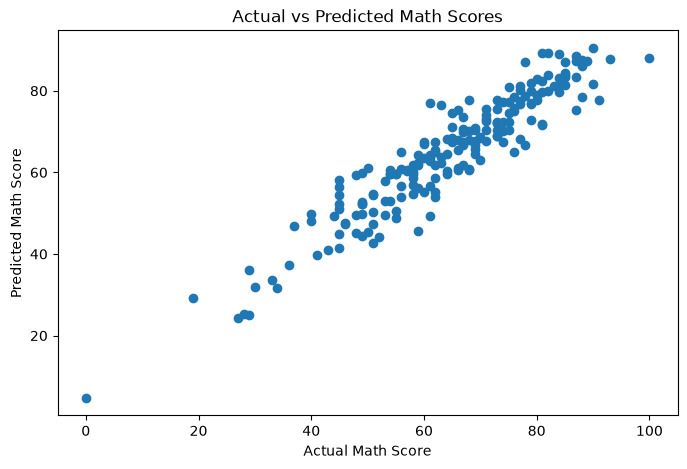

In [312]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Math Score")
plt.ylabel("Predicted Math Score")
plt.title("Actual vs Predicted Math Scores")

plt.savefig("../Images/actual_vs_predicted.png")

plt.show()

## 10. Model Evaluation

In [313]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 4.192441279544468
MSE: 28.936701731223703
RMSE: 5.379284499933398
R2 Score: 0.8810845237281757


In [314]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison["Error"] = comparison["Actual"] - comparison["Predicted"]

comparison.sort_values(
    by="Error",
    key=abs,
    ascending=False
).head(10)

,Actual,Predicted,Error
158,61,76.894121,-15.894121
265,59,45.538248,13.461752
318,63,76.428093,-13.428093
521,91,77.804404,13.195596
371,45,58.121273,-13.121273
451,100,88.066451,11.933549
859,87,75.256598,11.743402
867,61,49.271358,11.728642
816,45,56.430788,-11.430788
199,78,66.716398,11.283602


### Evaluation Metrics Interpretation

The Linear Regression model was evaluated using MAE, MSE, RMSE, and R² Score.

- **MAE (Mean Absolute Error):** Represents the average difference between actual and predicted math scores. Lower MAE indicates better predictions.

- **MSE (Mean Squared Error):** Measures the average squared difference between actual and predicted values. It gives higher importance to larger errors.

- **RMSE (Root Mean Squared Error):** Represents prediction error in the same unit as the target variable (math score). A lower RMSE indicates that predictions are closer to actual values.

- **R² Score:** Shows how much variation in the target variable is explained by the model. The model achieved an R² score of approximately 0.88, meaning it explains around 88% of the variation in students' math scores.

## 11. Feature Importance Analysis

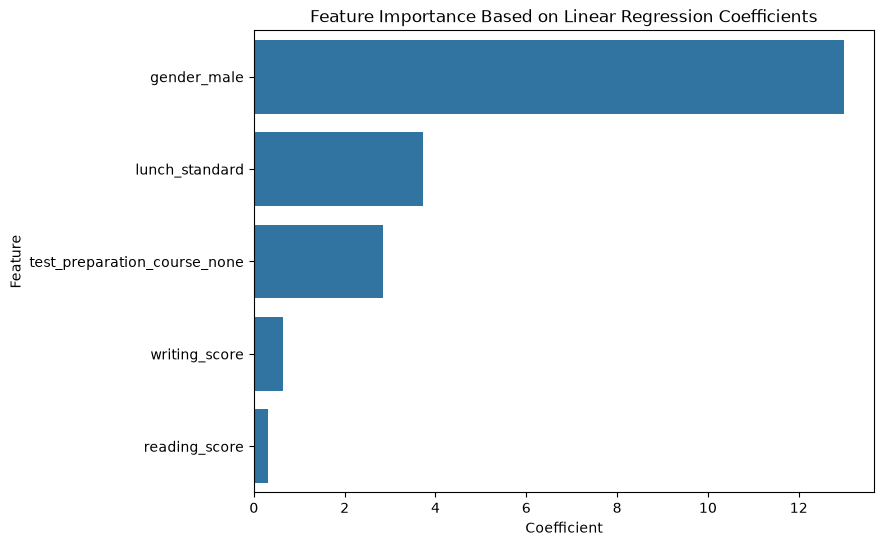

In [315]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=feature_importance,
    x="Coefficient",
    y="Feature"
)

plt.title("Feature Importance Based on Linear Regression Coefficients")
plt.savefig("../Images/feature_importance.png")
plt.show()

### Feature Importance Insights

The Linear Regression coefficients help identify which factors have the strongest influence on predicting students' mathematics scores.

### Key Findings:

- Reading and writing scores show a positive relationship with mathematics scores, indicating that academic performance in other subjects helps predict math performance.

- Test preparation course and lunch type show an association with mathematics performance.

- Gender also contributes to the prediction based on patterns learned from the dataset.

- Linear Regression coefficients help understand how each selected feature influences the predicted math score.

## 12. Saving the Trained Model

In [319]:
import pickle

with open("../student_performance_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully")

Model saved successfully


# Conclusion

This project successfully developed a Machine Learning model to predict students' mathematics scores using selected student-related factors.

The complete workflow included data cleaning, exploratory data analysis, feature engineering, categorical data encoding, model training, and evaluation.

The Linear Regression model achieved an R² score of approximately 0.88, showing strong predictive performance.

The analysis revealed that academic indicators such as reading and writing scores have a strong relationship with mathematics performance. Other factors such as test preparation course, lunch type, and gender also contribute to predicting student outcomes.

This project demonstrates how Machine Learning can be used to analyze educational data and identify important factors affecting student performance.